In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

In [2]:
DATA_DIR = '../data/splits/train_original.parquet'
df = pd.read_parquet(DATA_DIR)
df.head(5)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Hillshade_Range,Wilderness_Count,Soil_Count,Aspect_North_South,Aspect_East_West,Elevation_Slope_Interaction,Aspect_Cardinal_E,Aspect_Cardinal_N,Aspect_Cardinal_S,Aspect_Cardinal_W
0,0.551893,1.153850,-0.139758,0.175654,-0.192508,-0.474944,-1.088303,0.894536,1.358787,0.016526,...,-1.356861,0.0,0.0,0.121339,-1.695177,-0.047161,False,False,False,True
1,-0.494046,0.341045,0.628537,0.837801,-0.446862,-0.361235,-0.109795,1.828377,0.573896,-0.905968,...,-0.020158,0.0,0.0,-1.661407,-0.627846,0.577970,False,False,True,False
2,0.433316,-1.096993,1.062668,0.615909,0.256847,-0.667279,-0.279403,-1.673670,-1.024283,0.126077,...,0.514226,0.0,0.0,0.962374,0.531707,1.224307,False,True,False,False
3,-0.416785,-0.123414,-0.779115,-1.068070,-0.862279,-0.923532,0.774743,0.753948,-0.127794,0.313447,...,0.329325,0.0,0.0,-1.397015,0.636408,-0.827088,False,False,True,False
4,0.868122,0.501820,-0.605606,-1.068070,-0.544466,0.569467,-0.153066,1.499301,0.739660,-0.557672,...,-0.350102,0.0,0.0,-1.484095,-1.052413,-0.497759,False,False,True,False


# Imbalance Analysis and Mitigation

In this section, we analyze the class imbalance present in the dataset and we provide different approaches to mitigate it. Among these different techniques, we find SMOTE, ADASYN, Oversampling and Subsampling. After handling imbalance we will save each of the resulting balanced datasets to later train and test our models.

## Visualization of the Imbalance

In the graphic bellow we observe the class imbalance previously discussed in the EDA. We clearly see that there are 2 majority classes that dominate over the other 5.

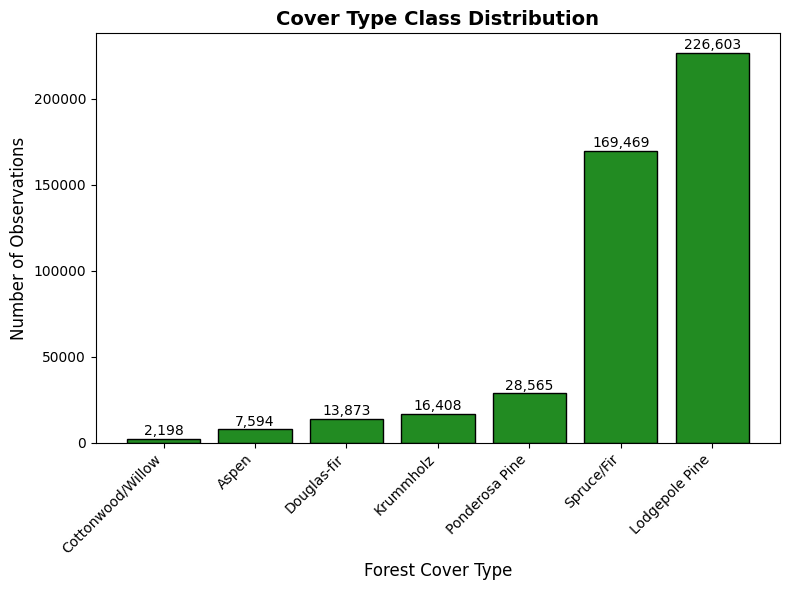

In [3]:
# Covertype Mapping
covertype_class = {
        1: 'Spruce/Fir', 2: 'Lodgepole Pine',
        3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
        5: 'Aspen', 6: 'Douglas-fir', 7:'Krummholz'
}

df['class_name'] = df['Cover_Type'].map(covertype_class)

class_counts = df['class_name'].value_counts().sort_values(ascending=True)
# Create bar chart
plt.figure(figsize=(8, 6))
plt.bar(class_counts.index, class_counts.values, color='forestgreen', edgecolor='black')

for i, (name, count) in enumerate(zip(class_counts.index, class_counts.values)):
        plt.text(i, count + 500, f'{count:,}', ha='center', va='bottom', fontsize=10)
plt.title('Cover Type Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Forest Cover Type', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Mitigation Approaches
* *Oversampling*: This approach consists on generating syntehtic data from the already existing one.
    * *SMOTE*
    * *ADASYN*
* *Undersampling*: This approach consists on removing data from the majority classes. The samples removed depend on the approach followed.
    * Controlled Under-sampling
        * *Random Undersampling*
        * *NearMiss*
    * Cleaning Under-sampling
        * *Tomek's Links*
        * *Edited Nearest Neighbors*

### OVERSAMPLING

#### SMOTE

In [5]:
from collections import Counter
X = df.drop(columns=['Cover_Type', 'class_name'], axis=1)
y = df['Cover_Type']

print(f"Shape of the dataset: {Counter(y)}")

Shape of the dataset: Counter({2: 226603, 1: 169469, 3: 28565, 7: 16408, 6: 13873, 5: 7594, 4: 2198})


In [5]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(X,y)
print(f"Shape of the dataset after SMOTE: {Counter(y_resampled)}")

Shape of the dataset after SMOTE: Counter({5: 283254, 2: 283254, 1: 283254, 7: 283254, 3: 283254, 6: 283254, 4: 283254})


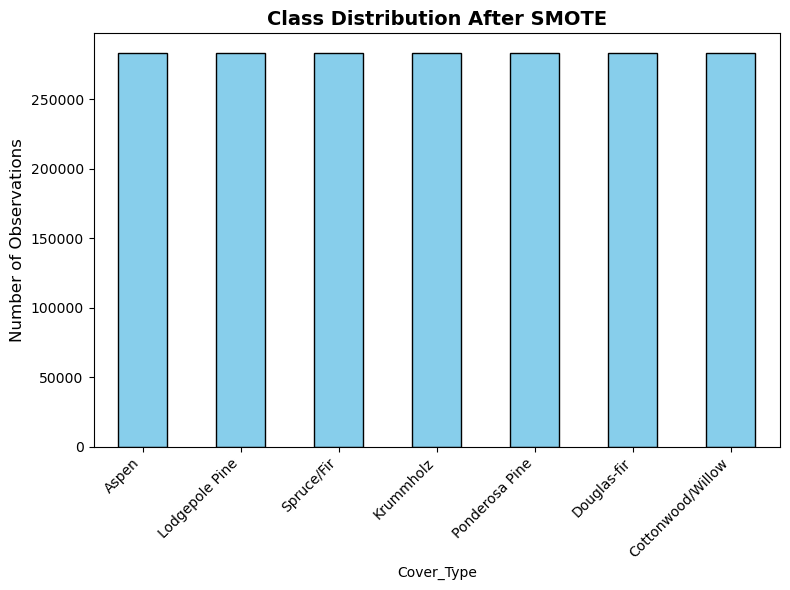

In [6]:
resampled_counts = pd.Series(y_resampled).map(covertype_class).value_counts()
plt.figure(figsize=(8, 6))
resampled_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution After SMOTE', fontsize=14, fontweight='bold')
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
df_resampled = pd.DataFrame(x_resampled, columns=X.columns)
df_resampled['Cover_Type'] = y_resampled

df_resampled.to_parquet('../data/processed/smote_balanced.parquet', index=False)

#### ADASYN

In [8]:
adasyn = ADASYN(random_state=42)
x_adasyn, y_adasyn = adasyn.fit_resample(X,y)
print(f"Shape of the dataset after ADASYN: {Counter(y_adasyn)}")

Shape of the dataset after ADASYN: Counter({2: 283254, 4: 283003, 7: 282879, 5: 282514, 3: 281980, 6: 280728, 1: 253489})


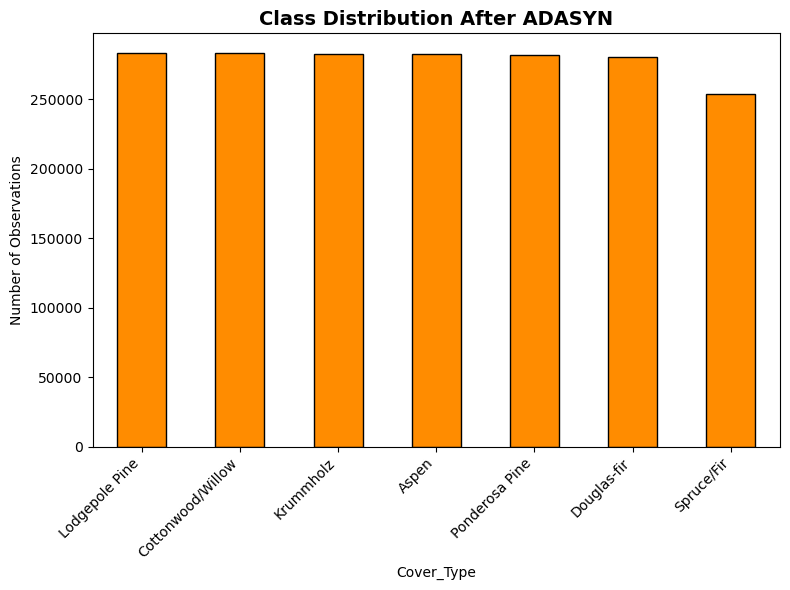

In [9]:
adasyn_counts = pd.Series(y_adasyn).map(covertype_class).value_counts()
plt.figure(figsize=(8, 6))
adasyn_counts.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Class Distribution After ADASYN', fontsize=14, fontweight='bold')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
df_resampled = pd.DataFrame(x_adasyn, columns=X.columns)
df_resampled['Cover_Type'] = y_adasyn

df_resampled.to_parquet('../data/processed/adasyn_balanced.parquet', index=False)

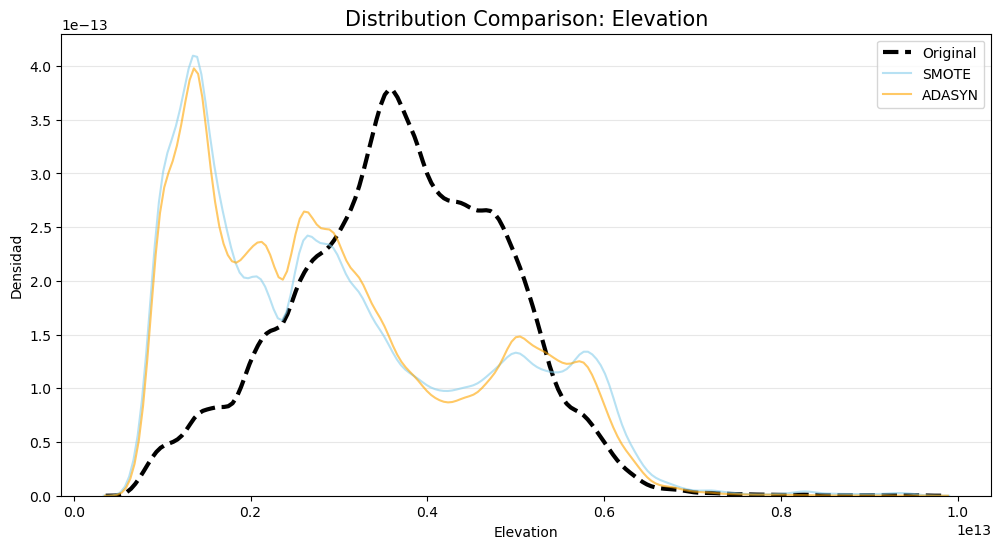

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

df_smote = pd.read_parquet('../data/processed/smote_balanced.parquet')
df_adasyn = pd.read_parquet('../data/processed/adasyn_balanced.parquet')

def plot_distribution_comparison(df_orig, df_smote, df_adasyn, feature='Elevation'):
    plt.figure(figsize=(12, 6))
    
    sns.kdeplot(df_orig[feature], label='Original', color='black', linewidth=3, linestyle='--')
    sns.kdeplot(df_smote[feature], label='SMOTE', color='skyblue', alpha=0.6)
    sns.kdeplot(df_adasyn[feature], label='ADASYN', color='orange', alpha=0.6)
    
    plt.title(f'Distribution Comparison: {feature}', fontsize=15)
    plt.xlabel(feature)
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_distribution_comparison(df, df_smote, df_adasyn, feature='Elevation')

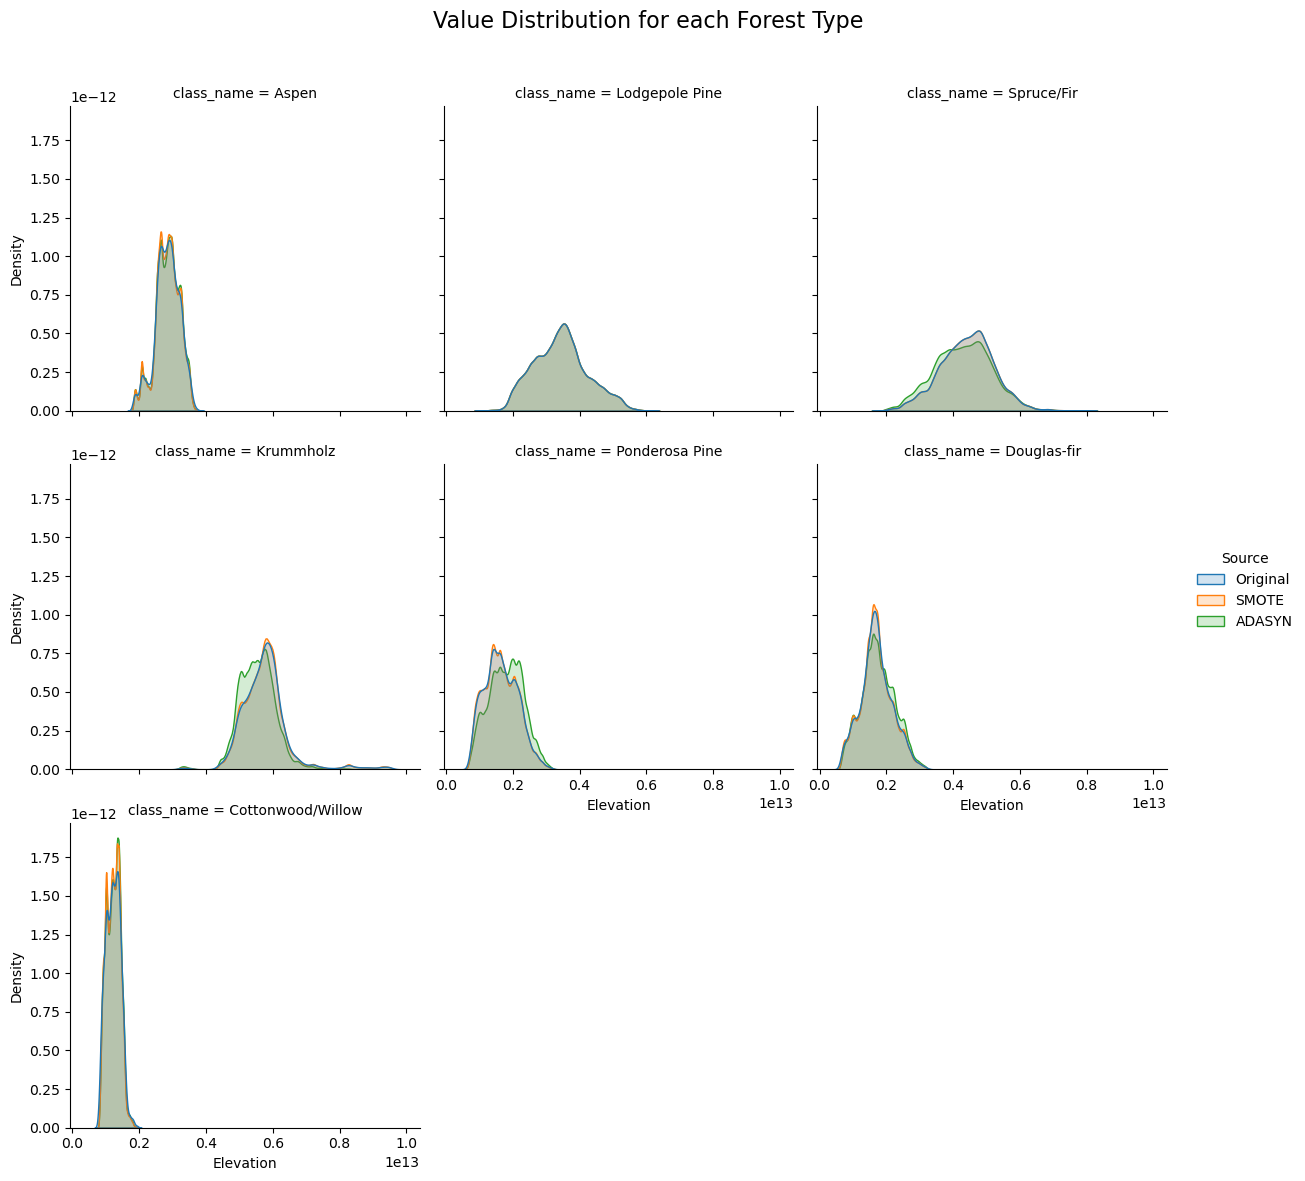

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_orig_plot = df[['Elevation', 'class_name']].copy()
df_orig_plot['Source'] = 'Original'

# arrays de salida de SMOTE/ADASYN a DataFrames
df_smote_plot = pd.DataFrame({
    'Elevation': x_resampled['Elevation'] if isinstance(x_resampled, pd.DataFrame) else x_resampled[:, X.columns.get_loc('Elevation')],
    'Cover_Type': y_resampled
})
df_smote_plot['class_name'] = df_smote_plot['Cover_Type'].map(covertype_class)
df_smote_plot['Source'] = 'SMOTE'

df_adasyn_plot = pd.DataFrame({
    'Elevation': x_adasyn['Elevation'] if isinstance(x_adasyn, pd.DataFrame) else x_adasyn[:, X.columns.get_loc('Elevation')],
    'Cover_Type': y_adasyn
})
df_adasyn_plot['class_name'] = df_adasyn_plot['Cover_Type'].map(covertype_class)
df_adasyn_plot['Source'] = 'ADASYN'

combined_df = pd.concat([df_orig_plot, df_smote_plot, df_adasyn_plot], axis=0)
combined_df = pd.concat([
    df_orig_plot[['Elevation', 'class_name', 'Source']],
    df_smote_plot[['Elevation', 'class_name', 'Source']],
    df_adasyn_plot[['Elevation', 'class_name', 'Source']],
], ignore_index=True)

# Grid
g = sns.displot(
    data=combined_df, 
    x='Elevation', 
    hue='Source', 
    col='class_name', 
    kind='kde', 
    col_wrap=3,
    height=4, 
    fill=True, 
    alpha=0.2,
    common_norm=False
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Value Distribution for each Forest Type', fontsize=16)
plt.show()

### UNDERSAMPLING

##### 1. Controlled Under-sampling

#### RANDOM UNDERSAMPLING

In [8]:
from imblearn.under_sampling import RandomUnderSampler

sampling_strategy = {
    1: 15000,
    2: 15000,
    3: 15000,
    4: 2198,
    5: 7594,
    6: 13873,
    7: 15000
}

moderate_undersampler = RandomUnderSampler(random_state=0, sampling_strategy=sampling_strategy)
x_moderate_undersample, y_moderate_undersample = moderate_undersampler.fit_resample(X,y)

equal_undersampler = RandomUnderSampler(random_state=0, sampling_strategy='all')
x_equal_undersample, y_equal_undersample = equal_undersampler.fit_resample(X,y)

print(f"Shape of the dataset after ModerateUnderSampler: {Counter(y_moderate_undersample)}")
print(f"Shape of the dataset after EqualUnderSampler: {Counter(y_equal_undersample)}")

Shape of the dataset after ModerateUnderSampler: Counter({1: 15000, 2: 15000, 3: 15000, 7: 15000, 6: 13873, 5: 7594, 4: 2198})
Shape of the dataset after EqualUnderSampler: Counter({1: 2198, 2: 2198, 3: 2198, 4: 2198, 5: 2198, 6: 2198, 7: 2198})


In [9]:
print(f"Shape of the dataset: {Counter(y)}")

Shape of the dataset: Counter({2: 226603, 1: 169469, 3: 28565, 7: 16408, 6: 13873, 5: 7594, 4: 2198})


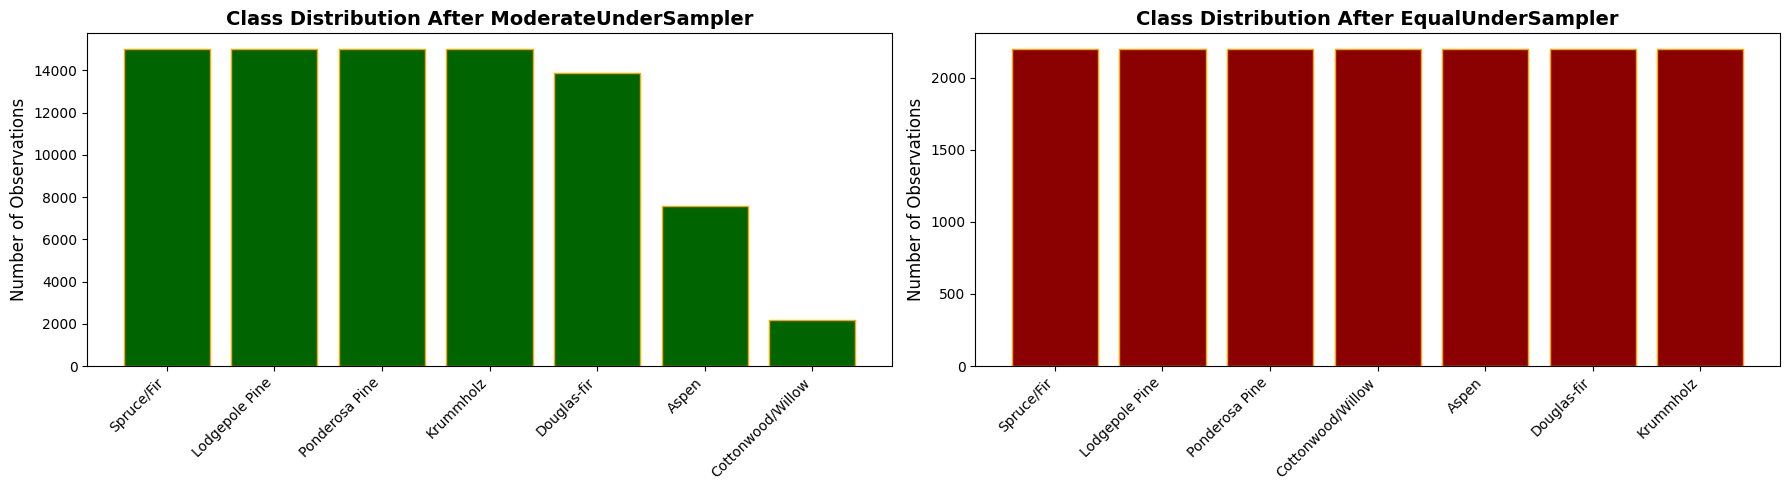

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(pd.Series(y_moderate_undersample).map(covertype_class).value_counts().index,
            pd.Series(y_moderate_undersample).map(covertype_class).value_counts().values,
            color='darkgreen', edgecolor='orange')
axes[0].set_title('Class Distribution After ModerateUnderSampler', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Observations', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

axes[1].bar(pd.Series(y_equal_undersample).map(covertype_class).value_counts().index,
            pd.Series(y_equal_undersample).map(covertype_class).value_counts().values,
            color='darkred', edgecolor='orange')
axes[1].set_title('Class Distribution After EqualUnderSampler', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Observations', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
df_moderate_undersampled = pd.DataFrame(x_moderate_undersample, columns=X.columns)
df_moderate_undersampled['Cover_Type'] = y_moderate_undersample

df_equal_undersampled = pd.DataFrame(x_equal_undersample, columns=X.columns)
df_equal_undersampled['Cover_Type'] = y_equal_undersample

df_moderate_undersampled.to_parquet('../data/processed/moderate_undersampled.parquet', index=False)
df_equal_undersampled.to_parquet('../data/processed/equal_undersampled.parquet', index=False)

#### NEARMISS

In [12]:
from imblearn.under_sampling import NearMiss

moderate_nm = NearMiss(sampling_strategy=sampling_strategy)
x_moderate_nm, y_moderate_nm = moderate_nm.fit_resample(X,y)

equal_nm = NearMiss(sampling_strategy='all')
x_equal_nm, y_equal_nm = equal_nm.fit_resample(X,y)

print(f"Shape of the dataset after ModerateUnderSampler: {Counter(y_moderate_nm)}")
print(f"Shape of the dataset after EqualUnderSampler: {Counter(y_equal_nm)}")

Shape of the dataset after ModerateUnderSampler: Counter({1: 15000, 2: 15000, 3: 15000, 7: 15000, 6: 13873, 5: 7594, 4: 2198})
Shape of the dataset after EqualUnderSampler: Counter({1: 2198, 2: 2198, 3: 2198, 4: 2198, 5: 2198, 6: 2198, 7: 2198})


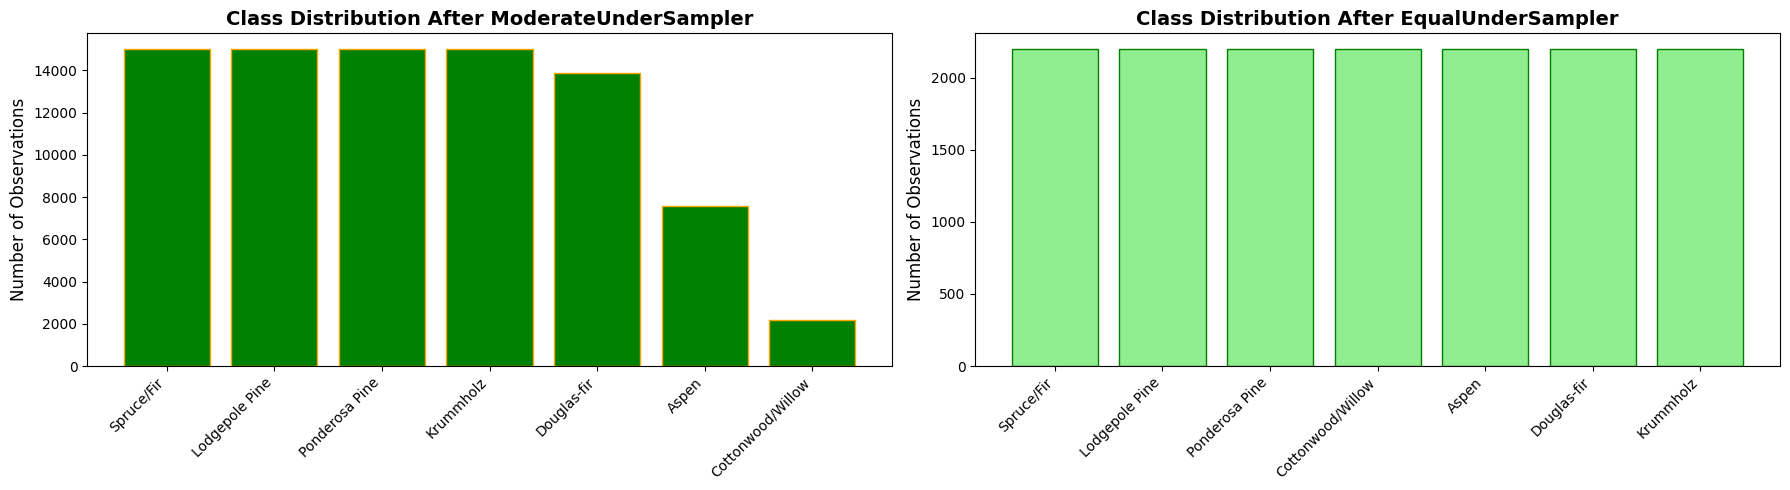

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(pd.Series(y_moderate_nm).map(covertype_class).value_counts().index,
            pd.Series(y_moderate_nm).map(covertype_class).value_counts().values,
            color='green', edgecolor='orange')
axes[0].set_title('Class Distribution After ModerateUnderSampler', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Observations', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

axes[1].bar(pd.Series(y_equal_nm).map(covertype_class).value_counts().index,
            pd.Series(y_equal_nm).map(covertype_class).value_counts().values,
            color='lightgreen', edgecolor='green')
axes[1].set_title('Class Distribution After EqualUnderSampler', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Observations', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
df_moderate_nm = pd.DataFrame(x_moderate_nm, columns=X.columns)
df_moderate_nm['Cover_Type'] = y_moderate_nm

df_equal_nm = pd.DataFrame(x_equal_nm, columns=X.columns)
df_equal_nm['Cover_Type'] = y_equal_nm

df_moderate_nm.to_parquet('../data/processed/NearMiss_moderate.parquet', index=False)
df_equal_nm.to_parquet('../data/processed/NearMiss_equal.parquet', index=False)

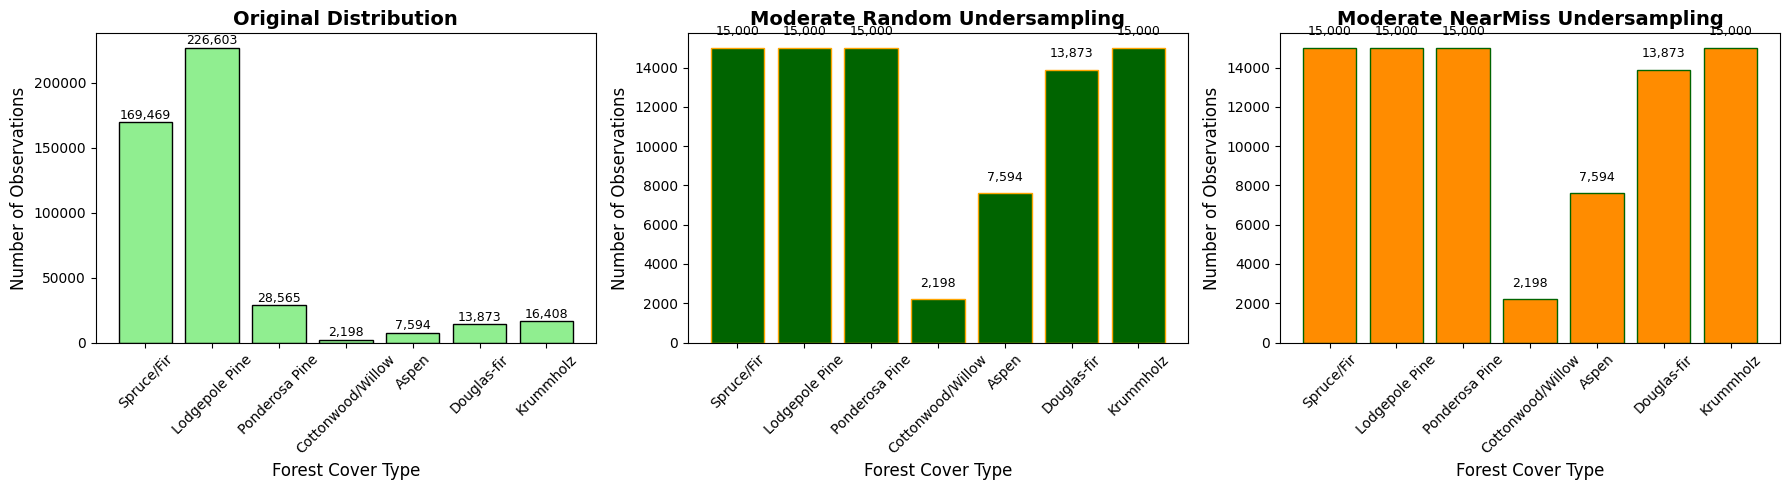

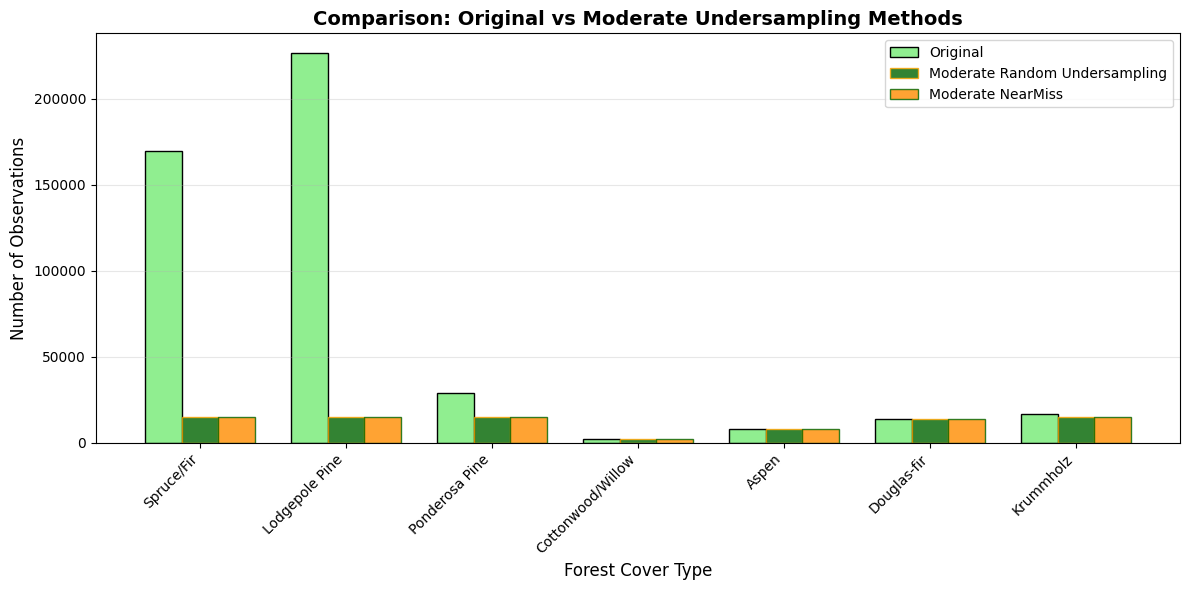

In [15]:
from collections import Counter

# Class counts for each approach
original_counts = Counter(y)
random_under_counts = Counter(y_moderate_undersample)
nearmiss_counts = Counter(y_moderate_nm)

comparison_data = []
for class_num in sorted(original_counts.keys()):
    comparison_data.append({
        'Class': covertype_class[class_num],
        'Original': original_counts[class_num],
        'Moderate Random Undersampling': random_under_counts[class_num],
        'Moderate NearMiss': nearmiss_counts[class_num]
    })

df_comparison = pd.DataFrame(comparison_data)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original distribution
axes[0].bar(df_comparison['Class'], df_comparison['Original'], color='lightgreen', edgecolor='black')
axes[0].set_title('Original Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Forest Cover Type', fontsize=12)
axes[0].set_ylabel('Number of Observations', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_comparison['Original']):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Moderate Random Undersampling distribution
axes[1].bar(df_comparison['Class'], df_comparison['Moderate Random Undersampling'], color='darkgreen', edgecolor='orange')
axes[1].set_title('Moderate Random Undersampling', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Forest Cover Type', fontsize=12)
axes[1].set_ylabel('Number of Observations', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_comparison['Moderate Random Undersampling']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Moderate NearMiss distribution
axes[2].bar(df_comparison['Class'], df_comparison['Moderate NearMiss'], color='darkorange', edgecolor='darkgreen')
axes[2].set_title('Moderate NearMiss Undersampling', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Forest Cover Type', fontsize=12)
axes[2].set_ylabel('Number of Observations', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_comparison['Moderate NearMiss']):
    axes[2].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Grouped bar chart for direct comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_comparison['Class']))
width = 0.25

bars1 = ax.bar([i - width for i in x], df_comparison['Original'], width, 
               label='Original', color='lightgreen', edgecolor='black')
bars2 = ax.bar([i for i in x], df_comparison['Moderate Random Undersampling'], width,
               label='Moderate Random Undersampling', color='darkgreen', edgecolor='orange', alpha=0.8)
bars3 = ax.bar([i + width for i in x], df_comparison['Moderate NearMiss'], width,
               label='Moderate NearMiss', color='darkorange', edgecolor='darkgreen', alpha=0.8)

ax.set_xlabel('Forest Cover Type', fontsize=12)
ax.set_ylabel('Number of Observations', fontsize=12)
ax.set_title('Comparison: Original vs Moderate Undersampling Methods', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Class'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##### 2. Cleaning Under-sampling

#### TOMEK'S LINKS

In [16]:
from imblearn.under_sampling import TomekLinks

tomek = TomekLinks()
x_tomek, y_tomek = tomek.fit_resample(X, y)

print(f"Shape of the dataset after Tomek's Links: {Counter(y_tomek)}")

df_tomek = pd.DataFrame(x_tomek, columns=X.columns)
df_tomek['Cover_Type'] = y_tomek

df_tomek.to_parquet('../data/processed/tomek_links.parquet', index=False)


Shape of the dataset after Tomek's Links: Counter({2: 220026, 1: 163515, 3: 27543, 7: 15952, 6: 12887, 5: 6893, 4: 2198})


#### EDITED NEAREST NEIGHBORS

In [ ]:
from imblearn.under_sampling import EditedNearestNeighbours

enn = EditedNearestNeighbours()

mode_enn = EditedNearestNeighbours(kind_sel = 'mode')
x_mode_enn, y_mode_enn = mode_enn.fit_resample(X,y)

df_mode_enn = pd.DataFrame(x_mode_enn, columns=X.columns)
df_mode_enn['Cover_Type'] = y_mode_enn

all_enn = EditedNearestNeighbours(kind_sel = 'all')
x_all_enn, y_all_enn = all_enn.fit_resample(X,y)

df_all_enn = pd.DataFrame(x_all_enn, columns=X.columns)
df_all_enn['Cover_Type'] = y_all_enn

In [ ]:
df_mode_enn.to_parquet('data/processed/editedNN/editedNN_mode.parquet', index=False)
df_all_enn.to_parquet('data/processed/editedNN/editedNN_all.parquet', index=False)

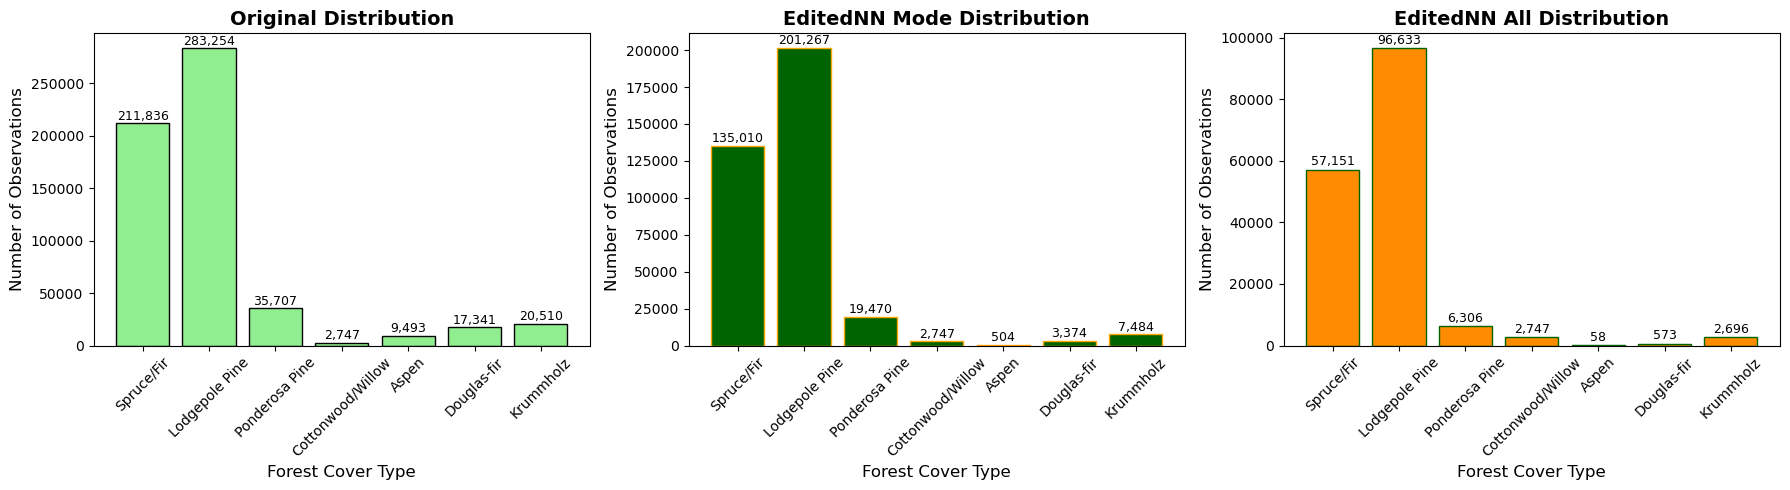

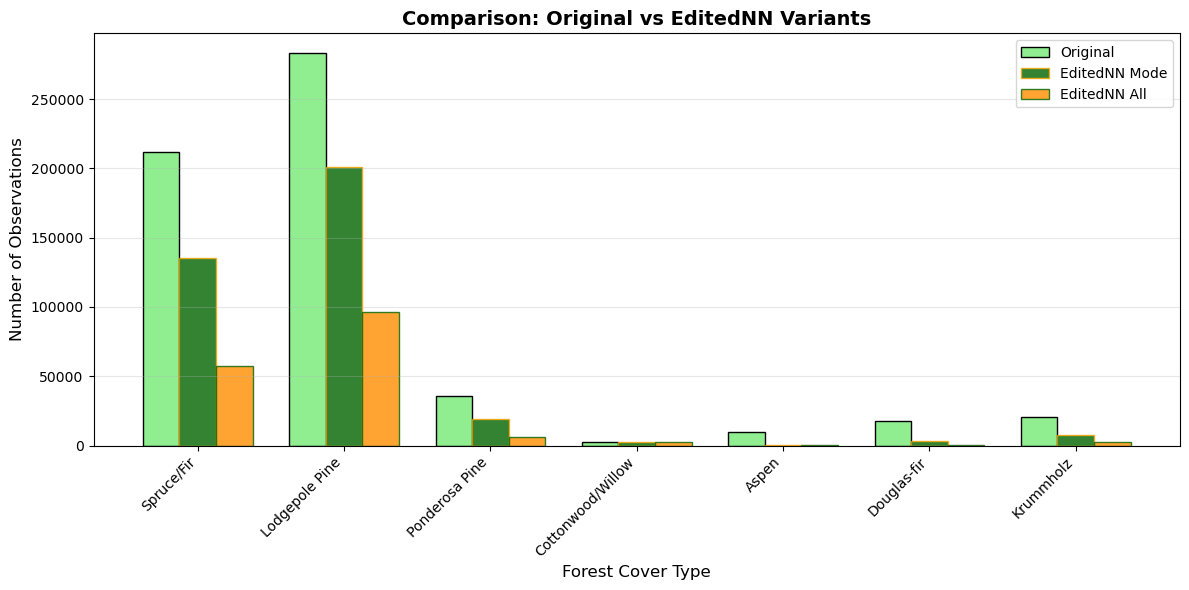

In [13]:
from collections import Counter
from pathlib import Path

mode_path = "../data/processed/editedNN/editedNN_mode.parquet"
all_path = "../data/processed/editedNN/editedNN_all.parquet"

df_mode_enn = pd.read_parquet(mode_path)
df_all_enn = pd.read_parquet(all_path)

# Class counts for each approach
original_counts = Counter(y)
mode_enn_counts = Counter(df_mode_enn['Cover_Type'])
all_enn_counts = Counter(df_all_enn['Cover_Type'])

comparison_data = []
for class_num in sorted(original_counts.keys()):
    comparison_data.append({
        'Class': covertype_class[class_num],
        'Original': original_counts.get(class_num, 0),
        'EditedNN Mode': mode_enn_counts.get(class_num, 0),
        'EditedNN All': all_enn_counts.get(class_num, 0)
    })

df_comparison = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original distribution
axes[0].bar(df_comparison['Class'], df_comparison['Original'], color='lightgreen', edgecolor='black')
axes[0].set_title('Original Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Forest Cover Type', fontsize=12)
axes[0].set_ylabel('Number of Observations', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_comparison['Original']):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

# EditedNN Mode distribution
axes[1].bar(df_comparison['Class'], df_comparison['EditedNN Mode'], color='darkgreen', edgecolor='orange')
axes[1].set_title('EditedNN Mode Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Forest Cover Type', fontsize=12)
axes[1].set_ylabel('Number of Observations', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_comparison['EditedNN Mode']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

# EditedNN All distribution
axes[2].bar(df_comparison['Class'], df_comparison['EditedNN All'], color='darkorange', edgecolor='darkgreen')
axes[2].set_title('EditedNN All Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Forest Cover Type', fontsize=12)
axes[2].set_ylabel('Number of Observations', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_comparison['EditedNN All']):
    axes[2].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Grouped bar chart for direct comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_comparison['Class']))
width = 0.25

ax.bar([i - width for i in x], df_comparison['Original'], width,
       label='Original', color='lightgreen', edgecolor='black')
ax.bar([i for i in x], df_comparison['EditedNN Mode'], width,
       label='EditedNN Mode', color='darkgreen', edgecolor='orange', alpha=0.8)
ax.bar([i + width for i in x], df_comparison['EditedNN All'], width,
       label='EditedNN All', color='darkorange', edgecolor='darkgreen', alpha=0.8)

ax.set_xlabel('Forest Cover Type', fontsize=12)
ax.set_ylabel('Number of Observations', fontsize=12)
ax.set_title('Comparison: Original vs EditedNN Variants',
             fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels(df_comparison['Class'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()